In [1689]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset
import os
from collections import defaultdict
from collections import Counter
from torch.optim.lr_scheduler import LambdaLR
import random
import torch.nn.functional as F
import numpy as np
import math
import matplotlib.pyplot as plt

In [1690]:
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)

data_folder = "./data/shakespeare-dataset-main/text"
text = ""
for root, _, files in os.walk(data_folder):
    for file in files:
        if file.endswith(".txt"):
            path = os.path.join(root, file)
            with open(path, 'r', encoding='utf-8') as f:
                text += f.read()

In [1691]:
def build_filtered_character_vocabulary(data_folder, min_freq=1e-5,padding_token='<PAD>', unknown_token='<UNK>'):
    all_text_parts = []
    print(f"Loading text files from: {data_folder}")
    for root, _, files in os.walk(data_folder):
        for file in files:
            if file.endswith(".txt"):
                path = os.path.join(root, file)
                try:
                    with open(path, 'r', encoding='utf-8') as f:
                        all_text_parts.append(f.read())
                except Exception as e:
                    print(f"Warning: Could not read {path}. Error: {e}")
    
    full_text_content = "".join(all_text_parts)
    print(f"Total characters loaded: {len(full_text_content)}")

    # 1. Calculate raw character counts
    char_counts = Counter(full_text_content)
    total_chars_in_corpus = len(full_text_content)

    # 2. Calculate frequencies and filter
    filtered_chars = []
    for char, count in char_counts.items():
        if count / total_chars_in_corpus >= min_freq:
            filtered_chars.append(char)
    
    # Sort for consistent ID assignment
    filtered_chars.sort()

    # 3. Build mappings with special tokens first
    char_to_idx = {}
    idx_to_char = {}
    current_idx = 0

    # Assign padding token to ID 0
    char_to_idx[padding_token] = current_idx
    idx_to_char[current_idx] = padding_token
    current_idx += 1

    # Assign unknown token to ID 1
    char_to_idx[unknown_token] = current_idx
    idx_to_char[current_idx] = unknown_token
    current_idx += 1

    # Add filtered common characters
    for char in filtered_chars:
        if char not in char_to_idx: # Ensure special tokens aren't re-added if they appear in text
            char_to_idx[char] = current_idx
            idx_to_char[current_idx] = char
            current_idx += 1

    vocab_size = len(char_to_idx)

    print(f"\nVocabulary built with {vocab_size} unique items (min_freq={min_freq}).")
    print(f"  Characters filtered out: {len(char_counts) - len(filtered_chars)}")
    print(f"  Padding Token: '{padding_token}' (ID: {char_to_idx[padding_token]})")
    print(f"  Unknown Token: '{unknown_token}' (ID: {char_to_idx[unknown_token]})")
    print(f"  Example char_to_idx (first 5): {list(char_to_idx.items())[:5]}...")
    print(f"  Example idx_to_char (first 5): {list(idx_to_char.items())[:5]}...")

    return char_to_idx, idx_to_char, vocab_size, full_text_content

char_to_idx, idx_to_char, vocab_size, full_text_content = build_filtered_character_vocabulary(data_folder,min_freq=1e-4)

Loading text files from: ./data/shakespeare-dataset-main/text
Total characters loaded: 5330336

Vocabulary built with 67 unique items (min_freq=0.0001).
  Characters filtered out: 19
  Padding Token: '<PAD>' (ID: 0)
  Unknown Token: '<UNK>' (ID: 1)
  Example char_to_idx (first 5): [('<PAD>', 0), ('<UNK>', 1), ('\t', 2), ('\n', 3), (' ', 4)]...
  Example idx_to_char (first 5): [(0, '<PAD>'), (1, '<UNK>'), (2, '\t'), (3, '\n'), (4, ' ')]...


In [1692]:
def devocab(seq):
    building = ""
    for x in seq:
        building += idx_to_char[int(x)]
    return building

In [1693]:
tokenized_text = []
building_sample = []

for let in text:
    if let in char_to_idx.keys():
        building_sample.append(char_to_idx[let])
    else:
        building_sample.append(char_to_idx['<UNK>'])

    if(let == '\n'):
        tokenized_text.append(building_sample)
        building_sample = []

In [1694]:
class BucketedBatchDataset(Dataset):
    def __init__(self, token_lists, batch_size=64, bucket_size=5, pad_token=char_to_idx["<PAD>"]):
        self.batches = []
        self.masks = []
        self.pad_token = pad_token

        # Step 1: Bucket sequences by length range
        buckets = defaultdict(list)
        for seq in token_lists:
            length = len(seq)
            bucket_min = (length // bucket_size) * bucket_size
            bucket_max = bucket_min + bucket_size

            buckets[(bucket_min, bucket_max)].append(seq)

        # Step 2: For each bucket, pad and batch sequences
        for (bucket_min, bucket_max), sequences in buckets.items():
            max_len = bucket_max
            padded_seqs = []
            attention_masks = []

            for seq in sequences:
                if(len(seq)<=5):
                    continue
                padding_len = max_len - len(seq)
                padded_seq = seq + [pad_token] * padding_len
                attention_mask = [1] * len(seq) + [0] * padding_len

                padded_seqs.append(torch.tensor(padded_seq, dtype=torch.long))
                attention_masks.append(torch.tensor(attention_mask, dtype=torch.long))

            # Create batches
            for i in range(0, len(padded_seqs), batch_size):
                batch = torch.stack(padded_seqs[i:i+batch_size])
                mask = torch.stack(attention_masks[i:i+batch_size])
                self.batches.append(batch)
                self.masks.append(mask)

    def __len__(self):
        return len(self.batches)

    def __getitem__(self, idx):
        return self.batches[idx], self.masks[idx]

shakespeare = list(BucketedBatchDataset(tokenized_text))

In [1695]:
def relative_position_bucket(rel_pos, num_buckets=32, max_distance=128, bidirectional=True):
    n = rel_pos
    if bidirectional:
        half = num_buckets // 2
        sign = (n < 0).to(torch.long)
        n = n.abs()
    else:
        half = 0
        sign = 0
        n = n.clamp(min=0)

    max_exact = num_buckets // 2
    is_small = n < max_exact
    val = torch.where(
        is_small,
        n,
        max_exact + (
            (torch.log(n.float() / max_exact + 1e-6) /
             math.log(max_distance / max_exact + 1e-6)) *
            (num_buckets - max_exact)
        ).to(torch.long).clamp(max=num_buckets - max_exact - 1)
    )
    return val + sign * half

In [1696]:
def get_diffusion_params(timesteps, s=0.008):
    with torch.no_grad():
        t_vals = torch.linspace(0, timesteps, steps=timesteps + 1, dtype=torch.float32)
        alpha_bar = torch.cos(((t_vals / timesteps) + s) / (1 + s) * math.pi / 2).pow(2)
        alpha_bar = (alpha_bar / alpha_bar[0]) + 1e-8
        alpha_bar.clamp_max(1.0)

        beta = 1 - (alpha_bar[1:] / alpha_bar[:-1]) 
        beta = torch.clamp(beta, 0.0001, 0.9999) # Clamp beta

        alpha = 1.0 - beta

        alpha_bar_prev = torch.cat([torch.tensor([1.0], device=device), alpha_bar[:-1].to(device)]) # Ensure device consistency

        return {
            "beta": beta.to(device),                  # beta_t for t=1 to T (length timesteps)
            "alpha": alpha_bar.to(device),                # alpha_t for t=1 to T (length timesteps)
            "alpha_prev": alpha_bar_prev.to(device),        # alpha_bar_t for t=0 to T (length timesteps + 1)
            # "tilde_beta": tilde_beta.to(device),    # For DDPM, not deterministic DDIM
        }

In [1697]:
class MultiheadAttentionWithRelBias(nn.Module):
    def __init__(self, embed_dim, num_heads, use_out_proj=True):
        super().__init__()
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads
        self.use_out_proj = use_out_proj

        assert self.head_dim * num_heads == embed_dim, "embed_dim must be divisible by num_heads"

        self.q_proj = nn.Linear(embed_dim, embed_dim)
        self.k_proj = nn.Linear(embed_dim, embed_dim)
        self.v_proj = nn.Linear(embed_dim, embed_dim)

        if use_out_proj:
            self.out_proj = nn.Linear(embed_dim, embed_dim)

        # T5-style: Learnable relative bias weights for each head.
        # This layer will project the 'embed_dim' of your rel_bias_emb
        # to 'num_heads' scalar biases, effectively learning how each head
        # should interpret the rich relative positional information.
        self.relative_attention_bias = nn.Linear(embed_dim, num_heads)

    def forward(self, x, rel_bias_emb, mask):
        # x: (batch_size, seq_len, embed_dim)
        # rel_bias_emb: (seq_len, seq_len, embed_dim)
        # This rel_bias_emb should ideally contain features for each (query_pos, key_pos) relative distance.
        batch_size, seq_len, _ = x.size()

        Q = self.q_proj(x).view(batch_size, seq_len, self.num_heads, self.head_dim)
        K = self.k_proj(x).view(batch_size, seq_len, self.num_heads, self.head_dim)
        V = self.v_proj(x).view(batch_size, seq_len, self.num_heads, self.head_dim)

        Q = Q.transpose(1, 2)  # (B, H, L, D_h)
        K = K.transpose(1, 2)  # (B, H, L, D_h)
        V = V.transpose(1, 2)  # (B, H, L, D_h)

        # Compute attention scores
        # (B, H, L, D_h) @ (B, H, D_h, L) -> (B, H, L, L)
        attn_scores = torch.matmul(Q, K.transpose(-2, -1)) / (self.head_dim ** 0.5)

        # Apply T5-style relative attention bias
        # rel_bias_emb: (L, L, E) -> project to (L, L, H) -> permute to (H, L, L) -> unsqueeze to (1, H, L, L)
        # This linear layer effectively learns the scalar bias for each head from the rich rel_bias_emb features.
        relative_bias = self.relative_attention_bias(rel_bias_emb) # (L, L, H)
        relative_bias = relative_bias.permute(2, 0, 1).unsqueeze(0) # (1, H, L, L)

        # Add the relative bias to the attention scores (logits)
        mkt = ((1-mask) * (-1e8)).unsqueeze(1).unsqueeze(2)
        attn_scores = attn_scores + relative_bias + mkt # Broadcasted (B, H, L, L)

        attn_weights = F.softmax(attn_scores, dim=-1)
        attn_output = torch.matmul(attn_weights, V)  # (B, H, L, D_h)

        # Concatenate heads and apply final linear layer
        attn_output = attn_output.transpose(1, 2).contiguous().view(batch_size, seq_len, self.embed_dim)

        if self.use_out_proj:
            attn_output = self.out_proj(attn_output)  # (B, L, E)

        return attn_output

In [1698]:
class ConvAttBlock(nn.Module):
    def __init__(self,embedding_dim=256,max_spatial=7,num_heads=4, hidden_size=1024):
            super().__init__()
            
            self.embedding_convs = nn.ModuleList()
            self.embedding_dim = embedding_dim
            self.max_spatial = max_spatial
            local_out_channels = self.embedding_dim // ((self.max_spatial+1)//2)
            self.num_heads = num_heads
            self.hidden_size = hidden_size

            for i in range(1, self.max_spatial+1,2):
                conv = nn.Conv1d(
                    in_channels=self.embedding_dim,
                    out_channels=local_out_channels,
                    kernel_size=i,
                    stride=1,
                    padding=(i-1)//2  # no internal padding, we do manual padding in forward
                )
                self.embedding_convs.append(conv)

            self.attend = MultiheadAttentionWithRelBias(embed_dim=self.embedding_dim,num_heads=self.num_heads)
            self.conv_layernm = nn.LayerNorm((self.embedding_dim))
            self.att_layernm = nn.LayerNorm((self.embedding_dim))

            self.gloop = nn.Sequential(
                nn.LayerNorm((self.embedding_dim)),
                nn.Dropout(0.1),
                nn.Linear(self.embedding_dim,self.hidden_size),
                nn.GELU(),
                nn.Linear(self.hidden_size,self.embedding_dim),
            )

    def conv_embed(self,x):
        out = []
        for conv in self.embedding_convs:
            out.append(conv(x))

            #print(conv(a).shape)
        return torch.cat(out,dim=1).transpose(2,1).transpose(1,2)
    
    def forward(self, x, pos, t, mask):
        p = x.transpose(1,2)
        pc = self.conv_embed(p).transpose(2,1)

        attended = self.attend(self.conv_layernm(pc + t),pos,mask)

        a = self.att_layernm(attended + x)
        
        return self.gloop(a)

In [1699]:
num_timesteps = 1000
class ConvDiffAtt(nn.Module):
    def __init__(self,embedding_dim=256,max_spatial=7, num_layers=3, num_heads=4, hidden_size=512,
                 vocab_size=vocab_size,num_timesteps=num_timesteps,pos_bucket_num=64,max_bucket_dist=128):
        super().__init__()

        self.embedding_dim = embedding_dim
        self.vocab_size = vocab_size
        self.max_spatial = max_spatial
        self.pos_bucket_num = pos_bucket_num
        self.max_bucket_dist=max_bucket_dist
        self.num_heads = num_heads
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.embedding_table_vocab = nn.Embedding(vocab_size,embedding_dim=self.embedding_dim)
        self.embedding_table_timesteps = nn.Embedding(num_timesteps,embedding_dim=self.embedding_dim)
        self.embedding_rel_buckets = nn.Embedding(pos_bucket_num,embedding_dim=self.embedding_dim)

        self.layers = nn.ModuleList()

        for _ in range(num_layers):
            a = ConvAttBlock(embedding_dim=self.embedding_dim,max_spatial=self.max_spatial,num_heads=self.num_heads,hidden_size=self.hidden_size)
            self.layers.append(
                a
            )

        #self.pos_emb = nn.Embedding(max_seq_len, embedding_dim)

    def rel_buckets(self,rel_pos_mat):
        a = relative_position_bucket(rel_pos_mat,self.pos_bucket_num,self.max_bucket_dist)
        return a
    
    def forward_with_embed(self,x, t, mask, tokens=True):
        """x of (B,seq)"""
        rel_pos_mat = torch.abs(torch.arange(0,x.shape[-1]).unsqueeze(0) - torch.arange(0,x.shape[-1]).unsqueeze(0).T).to(device)
        rel_pos_mat_embedded = self.embedding_rel_buckets(rel_pos_mat)

        x = self.embedding_table_vocab(x)

        time = self.embedding_table_timesteps(t).unsqueeze(1)

        for block in self.layers:
            x = block(x,rel_pos_mat_embedded,time, mask)

        print(self.embedding_table_vocab.weight.T.shape)

        if(tokens):
            return x @ self.embedding_table_vocab.weight.T
        else:
            return x

    def forward(self,x, t, mask, tokens=True):
        """x of (B,seq,embed_dim)"""
        rel_pos_mat = torch.abs(torch.arange(0,x.shape[-2]).unsqueeze(0) - torch.arange(0,x.shape[-2]).unsqueeze(0).T).to(device)
        rel_pos_mat_embedded = self.embedding_rel_buckets(rel_pos_mat)

        time = self.embedding_table_timesteps(t).unsqueeze(1)

        for block in self.layers:
            x = block(x,rel_pos_mat_embedded,time, mask)
        
        if(tokens):
            return x @ self.embedding_table_vocab.weight.T
        else:
            return x


model = ConvDiffAtt(vocab_size=vocab_size).to(device)

print(f"Num-Params : {sum([x.numel() for x in model.parameters()])}")

#print(shakespeare[0].unsqueeze(-1).shape)
ax = torch.tensor([0]*64).to(device)
print(shakespeare[0][0].shape)
print(shakespeare[0][1].shape)
print(model.forward_with_embed(shakespeare[0][0].to(device),ax,shakespeare[0][1].to(device)).shape)


x_t_current_emb = torch.randn_like(model.embedding_table_vocab(shakespeare[0][0].to(device)))


Num-Params : 2662668
torch.Size([64, 25])
torch.Size([64, 25])
torch.Size([256, 67])
torch.Size([64, 25, 67])


In [1700]:
class TransformerBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, ff_dim, drop=0.1):
        super().__init__()
        self.attn = MultiheadAttentionWithRelBias(embed_dim, num_heads)
        self.norm1 = nn.LayerNorm(embed_dim)

        self.drop = nn.Dropout(drop)

        self.ff = nn.Sequential(
            nn.Linear(embed_dim, ff_dim),
            nn.GELU(),
            nn.Linear(ff_dim, embed_dim)
        )
        self.norm2 = nn.LayerNorm(embed_dim)

    def forward(self, x, rel_pos_emb, mask):
        # x: (B, T, D), rel_pos_emb: (T, T, D), mask: (B, T) or (B, T, T)

        # Attention
        x = self.drop(x)

        x_attn = self.attn(x, rel_pos_emb, mask)

        x_attn = self.drop(x_attn)
        x = x + x_attn
        x = self.norm1(x)

        # Feedforward
        x_ff = self.drop(self.ff(x))
        x = x + x_ff
        x = self.norm2(x)

        return x

class TransformerDenoiser(nn.Module):
    def __init__(self, embedding_dim, num_heads, ff_dim, num_layers, num_buckets, vocab_size):
        super().__init__()
        self.embedding_dim = embedding_dim

        self.embedding_table_vocab = nn.Embedding(vocab_size,embedding_dim=self.embedding_dim)

        # Timestep embedding (sinusoidal or learned)
        self.time_embed = nn.Sequential(
            nn.Linear(embedding_dim, embedding_dim),
            nn.SiLU(),
            nn.Linear(embedding_dim, embedding_dim)
        )

        # Relative position buckets
        self.embedding_rel_buckets = nn.Embedding(num_buckets, embedding_dim)

        # Transformer layers
        self.layers = nn.ModuleList([
            TransformerBlock(embedding_dim, num_heads, ff_dim)
            for _ in range(num_layers)
        ])

    def forward_with_embed(self, x, t, mask, tokens=True):
        """
        x: (B, T, D)
        t: (B,)  - timesteps
        mask: attention mask (B, T) or (B, T, T)
        """
        B, T = x.shape
        device = x.device

        x = self.embedding_table_vocab(x)

        # Inject timestep embedding
        t_emb = self.get_timestep_embedding(t, self.embedding_dim).to(device)  # (B, D)
        t_emb = self.time_embed(t_emb)  # (B, D)
        x = x + t_emb.unsqueeze(1)     # (B, T, D)

        # Relative position bias
        rel_pos = torch.abs(torch.arange(T).unsqueeze(0) - torch.arange(T).unsqueeze(0).T).to(device)  # (T, T)
        rel_pos_emb = self.embedding_rel_buckets(rel_pos)  # (T, T, D)

        for layer in self.layers:
            x = layer(x, rel_pos_emb, mask)

        if(tokens):
            return x @ self.embedding_table_vocab.weight.T
        else:
            return x
    
    def forward(self,x, t, mask, tokens=True):
        """
        x: (B, T, D)
        t: (B,)  - timesteps
        mask: attention mask (B, T) or (B, T, T)
        """
        B, T, D = x.shape
        device = x.device

        # Inject timestep embedding
        t_emb = self.get_timestep_embedding(t, self.embedding_dim).to(device)  # (B, D)
        t_emb = self.time_embed(t_emb)  # (B, D)
        
        x = x + t_emb.unsqueeze(1)     # (B, T, D)

        # Relative position bias
        rel_pos = torch.abs(torch.arange(T).unsqueeze(0) - torch.arange(T).unsqueeze(0).T).to(device)  # (T, T)
        rel_pos_emb = self.embedding_rel_buckets(rel_pos)  # (T, T, D)

        for layer in self.layers:
            x = layer(x, rel_pos_emb, mask)

        if(tokens):
            return x @ self.embedding_table_vocab.weight.T
        else:
            return x


    def get_timestep_embedding(self, timesteps, dim):
        """
        Sinusoidal timestep embedding like in DDPM.
        timesteps: (B,)
        returns: (B, dim)
        """
        half_dim = dim // 2
        emb = torch.log(torch.tensor(10000.0)) / (half_dim - 1)
        emb = torch.exp(torch.arange(half_dim, device=timesteps.device) * -emb)
        emb = timesteps[:, None].float() * emb[None, :]
        emb = torch.cat([torch.sin(emb), torch.cos(emb)], dim=-1)
        if dim % 2 == 1:  # zero pad
            emb = F.pad(emb, (0, 1))
        return emb

model = TransformerDenoiser(384,4,256,6,128,vocab_size).to(device)

print(f"Num-Params : {sum([x.numel() for x in model.parameters()])}")

#print(shakespeare[0].unsqueeze(-1).shape)
ax = torch.tensor([0]*64).to(device)
print(shakespeare[0][0].shape)
print(shakespeare[0][1].shape)
print(model.forward_with_embed(shakespeare[0][0].to(device),ax,shakespeare[0][1].to(device)).shape)


x_t_current_emb = torch.randn_like(model.embedding_table_vocab(shakespeare[0][0].to(device)))


Num-Params : 5120664
torch.Size([64, 25])
torch.Size([64, 25])
torch.Size([64, 25, 67])


In [1701]:
learning_rate = 2e-5
epochs = 100
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)
diff_params = get_diffusion_params(num_timesteps)

def train_loop(dataset, model, optimizer, scheduler):
    size = len(tokenized_text)
    curr = 0
    model.train()
    average_epch_loss = 0.0
    for batch, X in enumerate(dataset):
        dv = X[0].to(device)
        mask = X[1].to(device)

        x0_emb = model.embedding_table_vocab(dv)
        #print(word_emb.shape)
        

        t_tens = torch.randint(0,num_timesteps,size = (dv.shape[0],),device=device)

        noise = torch.randn_like(x0_emb)
        alpha = diff_params["alpha"][t_tens].unsqueeze(1).unsqueeze(1)

        noisy_word = torch.sqrt(alpha)*x0_emb + torch.sqrt(1-alpha)*noise

        denoised = model(noisy_word,t_tens,mask,tokens=False)

        px0 = ((x0_emb - (torch.sqrt(1-alpha)*denoised))/torch.sqrt(alpha))
        denoised_tok = px0 @ model.embedding_table_vocab.weight.T

        loss_char = nn.CrossEntropyLoss(ignore_index=char_to_idx["<PAD>"])(denoised_tok.view(-1,denoised_tok.shape[-1]),dv.view(-1))
        loss_noise = nn.MSELoss()(denoised,noise)

        
        loss = loss_noise + loss_char
        loss.backward()

        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()
        
        curr += X[0].shape[0]
        average_epch_loss += loss.item() 
        if batch % 512 == 0:
            loss = loss.item()
            print(f"loss: {loss:>7f}  [{curr:>5d}/{size:>5d}]")
    return average_epch_loss/len(shakespeare)

def get_cosine_schedule_with_warmup(optimizer, warmup_steps, total_steps, min_lr=0.0):
    def lr_lambda(current_step):
        if current_step < warmup_steps:
            return float(current_step) / float(max(1, warmup_steps))
        progress = float(current_step - warmup_steps) / float(max(1, total_steps - warmup_steps))
        cosine_decay = 0.5 * (1 + math.cos(math.pi * progress))
        return max(min_lr, cosine_decay)

    return LambdaLR(optimizer, lr_lambda)

scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    warmup_steps=500,
    total_steps=len(shakespeare)*epochs,
)

for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    random.shuffle(shakespeare)
    aasd = train_loop(shakespeare, model, optimizer, scheduler)
    print(f"Average Loss : {aasd}")

    # See some samples at epcoh
    devocab(sample(50,1,50).squeeze(0))

    # Insanity check
    actu = shakespeare[0][0][0].unsqueeze(0).to(device)
    mask = shakespeare[0][1][0].unsqueeze(0).to(device)
    t_tens = torch.tensor([0]*1,device=device)
    logits = model.forward_with_embed(actu, t_tens, mask)

    sampled_idx = torch.multinomial(torch.softmax(logits, dim=-1).squeeze(0), 1).squeeze().long()
    greedy_idx = torch.argmax(logits, dim=-1).squeeze(0).squeeze().long()
    sampled_token = devocab(sampled_idx)
    greedy_token = devocab(greedy_idx)
    print(f"Actual in ds = {repr(devocab(shakespeare[0][0][0]))}")
    print(f"Model sampled at t=0 = {repr(sampled_token)}")
    print(f"Model greedy at t=0 = {repr(greedy_token)}")
    #print(devocab(torch.argmax(model(shakespeare[0].to(device),torch.tensor(0).to(device)),dim=-1)[0]))
    #print(devocab(gen_sample()[0]))

Epoch 1
-------------------------------
loss: 1.151451  [   64/182729]
loss: 1.078236  [32521/182729]
loss: 0.968984  [65069/182729]
loss: 0.927136  [97248/182729]
loss: 0.840804  [129672/182729]
Average Loss : 0.9819641891467666
torch.Size([1, 50, 384])
t-1000 tmk1-950
1000 - ',w<PAD>\nlsaaotalfesubleI<PAD>r\nvaEanAiAen<PAD>eo,\n<PAD> loasweeltd'
1000 - ',w<PAD>\nlsaaotalfesubleI<PAD>r\nvaEanAiAen<PAD>eo,\n<PAD> loasweeltd'
t-950 tmk1-900
950 - ',w<PAD>\nlsaaotalfesubleI<PAD>r\nvaEanAiAen<PAD>eo,\n<PAD> loasweeltd'
950 - ',w<PAD>\nlsaaotalfesubleI<PAD>r\nvaEanAiAen<PAD>eo,\n<PAD> loasweeltd'
t-900 tmk1-850
900 - ',w<PAD>\nlsaaotalfesubleI<PAD>r\nvaEanAiAen<PAD>eo,\n<PAD> loasweeltd'
900 - ',w<PAD>\nlsaaotalfesubleI<PAD>r\nvaEanAiAen<PAD>eo,\n<PAD> loasweeltd'
t-850 tmk1-800
850 - ',w<PAD>\nlsaaotalfesubleI<PAD>r\nvaEanAiAen<PAD>eo,\n<PAD> loasweeltd'
850 - ',w<PAD>\nlsaaotalfesubleI<PAD>r\nvaEanAiAen<PAD>eo,\n<PAD> loasweeltd'
t-800 tmk1-750
800 - ',w<PAD>\nlsaaotalfesubleI<PAD>r\nvaE

KeyboardInterrupt: 

In [1702]:
actu = shakespeare[10][0][0].unsqueeze(0).to(device)
mask = shakespeare[10][1][0].unsqueeze(0).to(device)
t_tens = torch.tensor([0]*1,device=device)
logits = model.forward_with_embed(actu, t_tens, mask)

sampled_idx = torch.multinomial(torch.softmax(logits, dim=-1).squeeze(0), 1).squeeze().long()
greedy_idx = torch.argmax(logits, dim=-1).squeeze(0).squeeze().long()
sampled_token = devocab(sampled_idx)
greedy_token = devocab(greedy_idx)
print(f"Actual in ds = {repr(devocab(shakespeare[10][0][0]))}")
print(f"Model sampled at t=0 = {repr(sampled_token)}")
print(f"Model greedy at t=0 = {repr(greedy_token)}")

Actual in ds = 'Alas, my father, it befits not me\n<PAD>'
Model sampled at t=0 = "AMas,?my'f\ttVHz,Ji=Rb<UNK>fVtjqnoJ me\nR"
Model greedy at t=0 = "AMas,?my'f\ttVHz,Ji=Rb<UNK>fVtjqnoJxme\nR"


torch.Size([1, 50, 384])
t-1000 tmk1-999
tensor([0.9979], device='mps:0')
############### px0
1000 - 'ts Fd ldi ho<PAD>oig na,<PAD> ,wo<PAD>ou aot. .nowsienrdM\nm\nan'
1000 - 'ts Fd ldi ho<PAD>oig na,<PAD> ,wo<PAD>ou aot. .nowsienrdM\nm\nan'
############### xt
1000 - 'th Fdd di ho<PAD>oig nM,<PAD> ,co<PAD><PAD>u aot. .nowsieordM\nm\na\n'
1000 - 'th Fdd di ho<PAD>oig na,<PAD> ,co<PAD><PAD>u aot. .nowsieordM\nm\na\n'
t-999 tmk1-998
tensor([0.8656], device='mps:0')
############### px0
999 - 'th nd  di ho<PAD>oig na,<PAD> ,co<PAD><PAD>u aot. .nowsieordM\n \na\n'
999 - 'th nd  di ho<PAD>oig na,<PAD> ,co<PAD><PAD>u aot. .nowsieordM\n \na\n'
############### xt
999 - 'ts Fd  di ho<PAD>oig na,<PAD> ,co<PAD><PAD>u aot. .nowsieordM\nm\na\n'
999 - 'ts Fd  di ho<PAD>oig na,<PAD> ,co<PAD><PAD>u aot. .nowsieordM\nm\na\n'
t-998 tmk1-997
tensor([0.7452], device='mps:0')
############### px0
998 - 'ts nd  di ho<PAD>oig na,<PAD> ,co<PAD><PAD>u aot. .nowsieordM\nm\na\n'
998 - 'ts nd  di ho<PAD>oig na,<PAD>

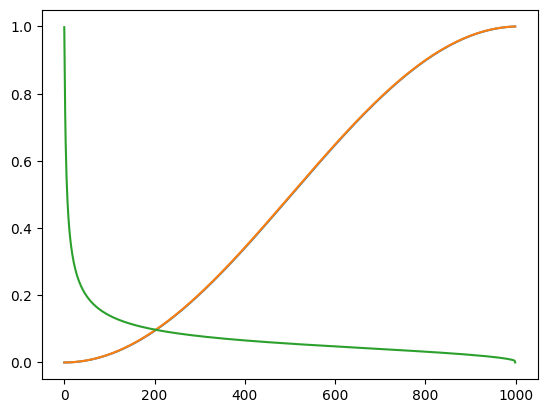

In [1712]:
a = []
atmk = []
si = []
def sample(sl,batch,k,temp=1.0,eta=1.0):
    with torch.no_grad():
        model.eval()
        xt = torch.randn((batch,sl,model.embedding_dim),device=device)
        #xt = model.embedding_table_vocab(torch.randint(0,vocab_size,(1,sl),device=device))
        print(xt.shape)
        for t in range(num_timesteps,0,-k):
            t_tens = torch.tensor([t]*batch,device=device)
            #print(t_tens)
            mask = torch.ones((batch,sl),device=device)
            noise = model(xt,t_tens,mask,tokens=False)

            #clamp
            # pred = torch.argmax(prediction_scores,-1).long()
            # denoised_word = self.model.bert.embeddings.word_embeddings(pred)

            print(f"t-{t} tmk1-{max(t-k,0)}")

            alpha_t = diff_params["alpha"][t_tens]
            alpha_tmk = diff_params["alpha"][max(t-k,0)]
            
            
            px0 = ((xt - (torch.sqrt(1-alpha_t)*noise))/torch.sqrt(alpha_t))

            sigma_t = eta * torch.sqrt((1-alpha_tmk)/(1-alpha_t)) * torch.sqrt(1-(alpha_t/alpha_tmk))

            a.append(alpha_t.item())
            atmk.append(alpha_tmk.item())
            si.append(sigma_t.item())

            print(sigma_t)

            xt = torch.sqrt(alpha_tmk) * px0 + (torch.sqrt(1 - alpha_tmk - sigma_t**2) * noise) + sigma_t * torch.randn_like(px0)

            if(t%1==0):
                print("#"*15,"px0")
                logits = px0 @ model.embedding_table_vocab.weight.T

                sampled_idx = torch.multinomial(torch.softmax(logits, dim=-1).squeeze(0), 1).squeeze().long()
                sampled_token = devocab(sampled_idx)
                print(f"{t} - {repr(sampled_token)}")

                print(f"{t} - {repr(devocab(torch.argmax(logits,-1).long().squeeze(0)))}")

                print("#"*15,"xt")
                logits = xt @ model.embedding_table_vocab.weight.T

                sampled_idx = torch.multinomial(torch.softmax(logits, dim=-1).squeeze(0), 1).squeeze().long()
                sampled_token = devocab(sampled_idx)
                print(f"{t} - {repr(sampled_token)}")

                print(f"{t} - {repr(devocab(torch.argmax(logits,-1).long().squeeze(0)))}")
                #print(logits.softmax(-1).max(dim=-1))

        
        pred = torch.argmax(logits,-1).long()
    model.train()
    return pred

devocab(sample(50,1,1,eta=1.0).squeeze(0))
plt.plot(a)
plt.plot(atmk)
plt.plot(si)